# Wine Quality: A Reproducible Data Workflow

**Author:** Cameron Doelling

**Dataset:** [UCI Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) (`winequality.csv`, red and white Portuguese *Vinho Verde* wines)

This project builds an end-to-end, reproducible data workflow on the UCI Wine Quality dataset:
the raw CSV is ingested, cleaned with documented and reusable functions, explored with summary
statistics and correlation checks, and communicated through three labelled visualizations.
No models are trained here — the goal is the dependable data foundation that later machine
learning work is built on, so every step is a plain function that another person can rerun and audit.

## 1. Setup

All randomness is seeded and all plotting defaults are set in one place so that a rerun of this
notebook, top to bottom, produces the same numbers and the same figures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("seaborn", sns.__version__)

numpy 2.2.1
pandas 2.2.3
matplotlib 3.10.0
seaborn 0.13.2


## 2. Data ingestion

The CSV lives next to this notebook and is committed to the repository, so the workflow runs
without a network connection and every rerun reads exactly the same bytes.

In [2]:
df = pd.read_csv("winequality.csv")
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.info()

Rows: 6,497   Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [4]:
def audit_columns(data):
    """Return a per-column audit of dtype, missing values and cardinality.

    Args:
        data (pd.DataFrame): Any dataframe to inspect.

    Returns:
        pd.DataFrame: One row per column with its dtype, the number and percentage
        of missing values, and the number of distinct non-null values. Used before
        and after cleaning to make the effect of each cleaning step visible.
    """
    return pd.DataFrame({
        "dtype": data.dtypes.astype(str),
        "n_missing": data.isna().sum(),
        "pct_missing": (data.isna().mean() * 100).round(2),
        "n_unique": data.nunique(dropna=True),
    })


audit_columns(df)

,dtype,n_missing,pct_missing,n_unique
fixed_acidity,float64,0,0.0,106
volatile_acidity,float64,0,0.0,187
citric_acid,float64,0,0.0,89
residual_sugar,float64,0,0.0,316
chlorides,float64,0,0.0,214
free_sulfur_dioxide,float64,0,0.0,135
total_sulfur_dioxide,float64,0,0.0,276
density,float64,0,0.0,998
pH,float64,0,0.0,108
sulphates,float64,0,0.0,111


## 3. Cleaning functions

Each cleaning step is a small, documented function that takes a dataframe and returns a **new**
dataframe. Nothing is modified in place, so any step can be rerun on its own without corrupting
earlier state, and the cleaning pipeline can be read as a list of decisions.

In [5]:
def standardize_columns(data):
    """Normalise column names and category labels to a predictable format.

    Column names are lowercased, stripped of surrounding whitespace, and any spaces
    or hyphens are replaced with underscores so that every column is accessible as a
    valid identifier. The `color` category labels are lowercased and stripped for the
    same reason: grouping breaks silently when 'Red' and 'red' are treated as two values.

    Args:
        data (pd.DataFrame): Raw dataframe as read from the CSV.

    Returns:
        pd.DataFrame: A copy with tidy column names and tidy category labels.
    """
    out = data.copy()
    out.columns = (
        out.columns.str.strip().str.lower().str.replace(r"[ \-]+", "_", regex=True)
    )
    if "color" in out.columns:
        out["color"] = out["color"].astype(str).str.strip().str.lower()
    return out


def remove_duplicate_records(data, subset=None):
    """Drop exact duplicate rows and report how many were removed.

    The Wine Quality data is a set of laboratory measurements in which the same physical
    sample can be recorded more than once, so identical rows carry no extra information
    while inflating the sample size and biasing summary statistics toward whichever wine
    profile happens to repeat most often. The first occurrence of each row is kept.

    Args:
        data (pd.DataFrame): Dataframe to deduplicate.
        subset (list[str] | None): Columns that define a duplicate. Defaults to all columns.

    Returns:
        pd.DataFrame: A copy with duplicate rows removed and the index reset.
    """
    n_before = len(data)
    out = data.drop_duplicates(subset=subset, keep="first").reset_index(drop=True)
    removed = n_before - len(out)
    print(f"remove_duplicate_records: dropped {removed:,} of {n_before:,} rows "
          f"({removed / n_before:.1%})")
    return out


def handle_missing_values(data, threshold=0.30):
    """Report missing values and impute the remaining gaps in a documented way.

    Columns missing more than `threshold` of their values are dropped, because imputing
    a majority of a column invents data rather than recovering it. Remaining numeric gaps
    are filled with the column median, which is robust to the skewed chemical measurements
    in this dataset, and categorical gaps are filled with the label 'unknown' so that
    missingness stays visible instead of being silently absorbed into an existing category.

    Args:
        data (pd.DataFrame): Dataframe to check and impute.
        threshold (float): Maximum share of missing values a column may have and be kept.

    Returns:
        pd.DataFrame: A copy with no missing values.
    """
    out = data.copy()
    missing_share = out.isna().mean()
    to_drop = missing_share[missing_share > threshold].index.tolist()
    if to_drop:
        print(f"handle_missing_values: dropping columns above {threshold:.0%} missing: {to_drop}")
        out = out.drop(columns=to_drop)

    total_missing = int(out.isna().sum().sum())
    if total_missing == 0:
        print("handle_missing_values: no missing values found; nothing to impute")
        return out

    for column in out.columns:
        if out[column].isna().any():
            if pd.api.types.is_numeric_dtype(out[column]):
                fill = out[column].median()
            else:
                fill = "unknown"
            print(f"handle_missing_values: filled {int(out[column].isna().sum())} "
                  f"values in '{column}' with {fill!r}")
            out[column] = out[column].fillna(fill)
    return out


def flag_extreme_values(data, columns=None, z_threshold=5.0):
    """Add a boolean column marking physically implausible or extreme measurements.

    Rather than deleting outliers, each row is flagged when any measured column sits more
    than `z_threshold` standard deviations from its mean. Extreme values in wine chemistry
    are often genuine (a very sweet wine really does have high residual sugar), so removing
    them would discard real signal; flagging keeps the decision explicit and reversible for
    anyone reading the notebook.

    Args:
        data (pd.DataFrame): Cleaned dataframe with numeric measurement columns.
        columns (list[str] | None): Columns to screen. Defaults to all numeric columns
            except the `quality` score.
        z_threshold (float): Number of standard deviations beyond which a value is extreme.

    Returns:
        pd.DataFrame: A copy with an added boolean column `is_extreme`.
    """
    out = data.copy()
    if columns is None:
        columns = [col for col in out.select_dtypes("number").columns if col != "quality"]
    z_scores = (out[columns] - out[columns].mean()) / out[columns].std()
    out["is_extreme"] = (z_scores.abs() > z_threshold).any(axis=1)
    print(f"flag_extreme_values: flagged {int(out['is_extreme'].sum()):,} rows "
          f"beyond {z_threshold} SD (kept, not dropped)")
    return out

### Why these cleaning steps were necessary

The audit above surfaced three concrete problems, and each cleaning function addresses one of them.

**Inconsistent naming.** The column labels arrive in mixed case (`pH` alongside `alcohol`), and the
`color` values are free text. Any grouping or column lookup that assumes one convention breaks
silently on the other — `groupby("color")` would treat `'Red'` and `'red'` as two separate wines
styles — so `standardize_columns()` forces a single lowercase, underscore-separated convention
before anything else touches the data.

**Duplicate records.** 1,177 of the 6,497 rows are exact copies of another row. Duplicates add no
information about wine chemistry, but they do pull every mean, correlation and plot toward whichever
wine profiles happen to repeat. Left in place they would have inflated the sample size by 18% and
biased every result below, so `remove_duplicate_records()` keeps only the first occurrence.

**Unverified completeness and extreme values.** A workflow cannot assume a file is complete just
because it looks tidy, so `handle_missing_values()` checks and reports rather than trusting the
source; here it confirmed there are no gaps to impute. `flag_extreme_values()` then marks the rows
with measurements beyond five standard deviations, which keeps unusual-but-real wines in the sample
while making them easy to exclude from any later sensitivity check.

The steps run in a fixed order — names first, then duplicates, then missing values, then the
outlier flag — so the output is a deterministic function of the raw CSV.

In [6]:
df_clean = (
    df.pipe(standardize_columns)
      .pipe(remove_duplicate_records)
      .pipe(handle_missing_values)
      .pipe(flag_extreme_values)
)

print(f"\nraw:     {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"cleaned: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
df_clean.head()

remove_duplicate_records: dropped 1,177 of 6,497 rows (18.1%)
handle_missing_values: no missing values found; nothing to impute
flag_extreme_values: flagged 62 rows beyond 5.0 SD (kept, not dropped)

raw:     6,497 rows x 13 columns
cleaned: 5,320 rows x 14 columns


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,color,is_extreme
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,False
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red,False


In [7]:
audit_columns(df_clean)

,dtype,n_missing,pct_missing,n_unique
fixed_acidity,float64,0,0.0,106
volatile_acidity,float64,0,0.0,187
citric_acid,float64,0,0.0,89
residual_sugar,float64,0,0.0,316
chlorides,float64,0,0.0,214
free_sulfur_dioxide,float64,0,0.0,135
total_sulfur_dioxide,float64,0,0.0,276
density,float64,0,0.0,998
ph,float64,0,0.0,108
sulphates,float64,0,0.0,111


## 4. Exploratory analysis functions

The EDA is also written as reusable functions: a summary-statistics view, a grouped view, and a
correlation check against the target variable.

In [8]:
def summarize_numeric(data, round_to=3):
    """Summarise every numeric column with spread, skew and missingness in one table.

    Extends `DataFrame.describe()` with the median, the interquartile range and the skew,
    which together reveal the asymmetry of the chemical measurements that a mean and a
    standard deviation alone would hide.

    Args:
        data (pd.DataFrame): Dataframe to summarise.
        round_to (int): Decimal places for the returned values.

    Returns:
        pd.DataFrame: One row per numeric column with count, mean, std, min, quartiles,
        max, IQR, skew and the number of missing values.
    """
    numeric = data.select_dtypes("number")
    summary = numeric.describe().T
    summary["median"] = numeric.median()
    summary["iqr"] = numeric.quantile(0.75) - numeric.quantile(0.25)
    summary["skew"] = numeric.skew()
    summary["n_missing"] = numeric.isna().sum()
    return summary.round(round_to)


summarize_numeric(df_clean)

,count,mean,std,min,25%,50%,75%,max,median,iqr,skew,n_missing
fixed_acidity,5320.0,7.215,1.320,3.800,6.400,7.000,7.700,15.900,7.000,1.300,1.650,0
volatile_acidity,5320.0,0.344,0.168,0.080,0.230,0.300,0.410,1.580,0.300,0.180,1.505,0
citric_acid,5320.0,0.318,0.147,0.000,0.240,0.310,0.400,1.660,0.310,0.160,0.484,0
residual_sugar,5320.0,5.048,4.500,0.600,1.800,2.700,7.500,65.800,2.700,5.700,1.707,0
chlorides,5320.0,0.057,0.037,0.009,0.038,0.047,0.066,0.611,0.047,0.028,5.338,0
free_sulfur_dioxide,5320.0,30.037,17.805,1.000,16.000,28.000,41.000,289.000,28.000,25.000,1.363,0
total_sulfur_dioxide,5320.0,114.109,56.774,6.000,74.000,116.000,153.250,440.000,116.000,79.250,0.064,0
density,5320.0,0.995,0.003,0.987,0.992,0.995,0.997,1.039,0.995,0.005,0.666,0
ph,5320.0,3.225,0.160,2.720,3.110,3.210,3.330,4.010,3.210,0.220,0.390,0
sulphates,5320.0,0.533,0.150,0.220,0.430,0.510,0.600,2.000,0.510,0.170,1.809,0


In [9]:
def profile_by_group(data, group_column, value_columns=None, round_to=3):
    """Compare mean measurements across the levels of a categorical column.

    Args:
        data (pd.DataFrame): Cleaned dataframe.
        group_column (str): Categorical column to group by, e.g. 'color' or 'quality'.
        value_columns (list[str] | None): Numeric columns to average. Defaults to all.
        round_to (int): Decimal places for the returned values.

    Returns:
        pd.DataFrame: Group sizes plus the mean of each requested numeric column.
    """
    if value_columns is None:
        value_columns = data.select_dtypes("number").columns.tolist()
    grouped = data.groupby(group_column)[value_columns].mean()
    grouped.insert(0, "n_wines", data.groupby(group_column).size())
    return grouped.round(round_to)


profile_by_group(df_clean, "color")

,n_wines,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
color,,,,,,,,,,,,,
red,1359,8.311,0.529,0.272,2.523,0.088,15.893,46.826,0.997,3.310,0.659,10.432,5.623
white,3961,6.839,0.281,0.334,5.915,0.046,34.889,137.194,0.994,3.195,0.490,10.589,5.855


In [10]:
profile_by_group(df_clean, "quality", ["alcohol", "volatile_acidity", "citric_acid",
                                       "density", "chlorides", "sulphates"])

,n_wines,alcohol,volatile_acidity,citric_acid,density,chlorides,sulphates
quality,,,,,,,
3,30,10.215,0.517,0.281,0.996,0.077,0.506
4,206,10.215,0.462,0.272,0.995,0.061,0.507
5,1752,9.872,0.394,0.306,0.996,0.066,0.529
6,2323,10.649,0.316,0.325,0.994,0.054,0.534
7,856,11.511,0.292,0.336,0.993,0.045,0.550
8,148,11.912,0.303,0.341,0.992,0.040,0.519
9,5,12.180,0.298,0.386,0.991,0.027,0.466


In [11]:
def correlations_with(data, target="quality", round_to=3):
    """Rank numeric columns by their linear correlation with a target column.

    Args:
        data (pd.DataFrame): Cleaned dataframe.
        target (str): Column to correlate everything else against.
        round_to (int): Decimal places for the returned values.

    Returns:
        pd.Series: Correlations sorted from strongest positive to strongest negative,
        excluding the target's correlation with itself.
    """
    numeric = data.select_dtypes("number")
    correlations = numeric.corr(numeric_only=True)[target].drop(labels=[target])
    return correlations.sort_values(ascending=False).round(round_to)


correlations_with(df_clean, "quality")

alcohol                 0.469
citric_acid             0.098
free_sulfur_dioxide     0.054
sulphates               0.042
ph                      0.040
total_sulfur_dioxide   -0.050
residual_sugar         -0.057
fixed_acidity          -0.080
chlorides              -0.202
volatile_acidity       -0.265
density                -0.326
Name: quality, dtype: float64

## 5. Visualizations

Three figures, each with a title and labelled axes. They are saved to `figures/` so the written
report can reference exactly the images produced by this run.

**Figure 1 — How quality scores are distributed.** Before reading anything into the drivers of
quality, it is worth seeing how imbalanced the target is and whether red and white wines are
scored differently.

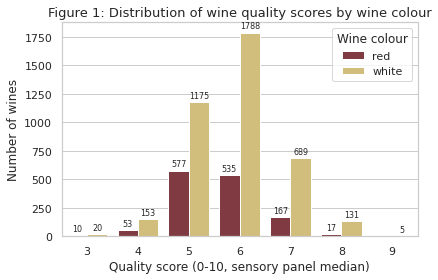

In [12]:
fig, ax = plt.subplots()
sns.countplot(data=df_clean, x="quality", hue="color",
              palette={"red": "#8c2f39", "white": "#e0c56e"}, ax=ax)
ax.set_title("Figure 1: Distribution of wine quality scores by wine colour")
ax.set_xlabel("Quality score (0-10, sensory panel median)")
ax.set_ylabel("Number of wines")
ax.legend(title="Wine colour")
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)
fig.tight_layout()
fig.savefig("figures/figure1_quality_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation of Figure 1.** The target variable is severely imbalanced. Scores of 5 and 6
account for 4,075 of the 5,320 cleaned wines (77%), while the two extremes together — 30 wines
scored 3 and 5 scored 9 — make up less than 1%. White wines outnumber red roughly three to one at
every score. Two consequences follow for the rest of the analysis: any claim about excellent or
poor wines rests on a handful of observations, and any statistic pooled across both colours is
effectively a statistic about white wine.

**Figure 2 — How the chemical measurements relate to each other.** A correlation heatmap shows
both which variables track quality and which variables duplicate each other, which matters for
any modelling that follows this workflow.

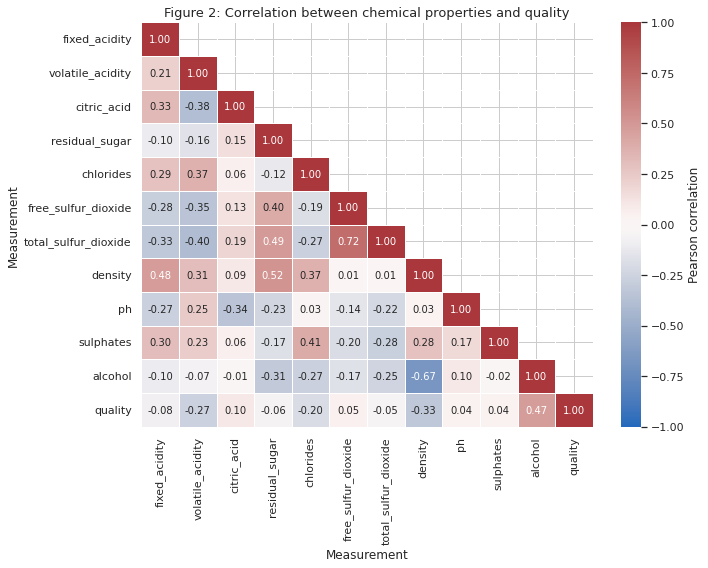

In [13]:
numeric_cols = [col for col in df_clean.select_dtypes("number").columns]
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Figure 2: Correlation between chemical properties and quality")
ax.set_xlabel("Measurement")
ax.set_ylabel("Measurement")
fig.tight_layout()
fig.savefig("figures/figure2_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation of Figure 2.** Reading the bottom `quality` row, alcohol is the strongest positive
correlate (r = 0.47) and density (-0.33) and volatile acidity (-0.27) the strongest negative ones;
everything else sits within ±0.2 of zero, including citric acid and residual sugar. The rest of the
matrix shows heavy redundancy among the predictors themselves: density moves with residual sugar
(0.52) and against alcohol (-0.67), and free and total sulphur dioxide correlate at 0.72. Density's
negative link to quality is therefore largely alcohol's relationship restated, and a later model
would gain little from carrying all of these measurements at once.

**Figure 3 — The strongest single relationship.** Alcohol has the largest positive correlation
with quality, so a boxplot per quality score shows whether that relationship is a steady trend or
an artefact of the sparsely populated extreme scores.

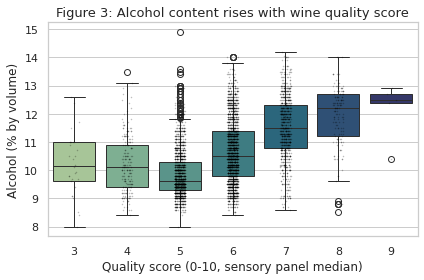

In [14]:
fig, ax = plt.subplots()
sns.boxplot(data=df_clean, x="quality", y="alcohol", hue="quality",
            palette="crest", legend=False, ax=ax)
sns.stripplot(data=df_clean, x="quality", y="alcohol", color="black",
              size=1.5, alpha=0.25, ax=ax)
ax.set_title("Figure 3: Alcohol content rises with wine quality score")
ax.set_xlabel("Quality score (0-10, sensory panel median)")
ax.set_ylabel("Alcohol (% by volume)")
fig.tight_layout()
fig.savefig("figures/figure3_alcohol_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation of Figure 3.** The relationship is a genuine trend, not an artefact of the sparse
tails: median alcohol climbs steadily from 9.6% at score 5 to 10.5%, 11.5% and 12.2% at scores 6, 7
and 8.
The boxes also overlap heavily, so alcohol separates the groups on average without predicting any
individual wine's score, and the widest boxes sit at the extreme scores where only a few dozen
wines exist. Note that the trend is flat or slightly reversed between scores 3, 4 and 5, so this is
not a strictly monotonic relationship across the whole scale.

**Figure 4 — Two drivers at once.** Volatile acidity is among the strongest negative correlates of
quality; plotting it against alcohol shows how the two combine, separately for red and white wine.

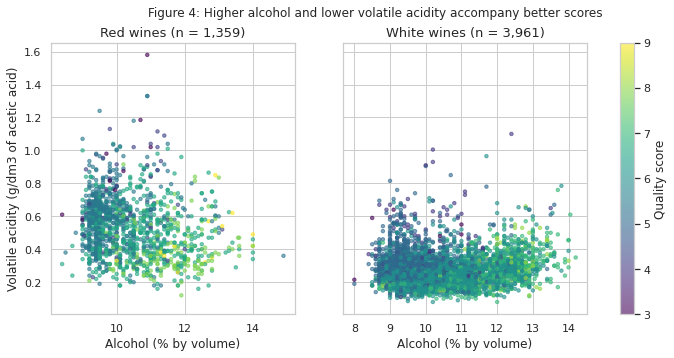

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, colour in zip(axes, ["red", "white"]):
    subset = df_clean[df_clean["color"] == colour]
    points = ax.scatter(subset["alcohol"], subset["volatile_acidity"],
                        c=subset["quality"], cmap="viridis", s=12, alpha=0.6)
    ax.set_title(f"{colour.capitalize()} wines (n = {len(subset):,})")
    ax.set_xlabel("Alcohol (% by volume)")
axes[0].set_ylabel("Volatile acidity (g/dm3 of acetic acid)")
fig.colorbar(points, ax=axes, label="Quality score")
fig.suptitle("Figure 4: Higher alcohol and lower volatile acidity accompany better scores")
fig.savefig("figures/figure4_alcohol_vs_volatile_acidity.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation of Figure 4.** Red and white wines occupy visibly different regions: reds spread
across volatile acidity from 0.12 to 1.58 g/dm3, while whites cluster tightly below 0.5. Within each
panel the brighter (higher-scoring) points concentrate toward the lower right — more alcohol, less
volatile acidity — which is the two-variable version of the pattern Figures 2 and 3 showed one
variable at a time. The effect is clearer in reds; among whites, colour varies mostly along the
alcohol axis, suggesting volatile acidity matters less for white wine at the low levels it reaches
there.

## 6. Save the cleaned dataset

Writing the cleaned table to disk separates the expensive, decision-heavy cleaning step from any
later analysis, and gives the exact input that a future modelling notebook would consume.

In [16]:
df_clean.to_csv("winequality_clean.csv", index=False)
print(f"Saved winequality_clean.csv: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

Saved winequality_clean.csv: 5,320 rows x 14 columns


## 7. Summary and interpretation

**What the dataset contains.** The raw file holds 6,497 Portuguese *Vinho Verde* wines (1,599 red
and 4,898 white), each described by eleven physicochemical laboratory measurements, a sensory
quality score from 0 to 10, and a colour label. After cleaning, 5,320 distinct wines remain.

**What the cleaning revealed.** The single largest data-quality issue was duplication: 1,177 rows —
roughly 18% of the file — were exact copies of another row. That is unsurprising for laboratory
measurements, where two bottles of the same wine can produce identical readings, but leaving those
rows in place would have overweighted the most common wine profiles in every average and every
correlation reported below. There were no missing values in any column, so the missing-value
function reported and confirmed that rather than imputing anything. Sixty-two rows carry
measurements more than five standard deviations from their column mean; these were flagged rather
than deleted, because extreme sweetness or high sulphur dioxide is chemically plausible in real wine.

**Patterns worth noting.** Quality scores are heavily concentrated in the middle of the scale:
scores of 5 and 6 account for 77% of wines, while the extremes (3 and 9) together account for less
than 1% (Figure 1). Alcohol content is the strongest single correlate of quality (r ≈ 0.47) and the
relationship is visibly monotonic from score 5 upward (Figure 3). The strongest negative correlates
are density (r ≈ -0.33), which is itself largely a function of sugar and alcohol content, and
volatile acidity (r ≈ -0.27) — the acetic acid that gives wine a vinegary character. Figure 2 also shows that several measurements are near-duplicates
of each other: density moves closely with residual sugar and inversely with alcohol, and free and
total sulphur dioxide are strongly related, which means a later model would gain little from
carrying all of them. Red and white wines form clearly different chemical populations (Figure 4):
white wines average more than twice the residual sugar and nearly three times the total sulphur
dioxide of reds, yet their mean quality scores differ only slightly (5.85 versus 5.62).

**What surprised me.** Two things. First, how much of the dataset was duplicated — an 18% inflation
that no summary statistic would have exposed without an explicit check. Second, that the variables
usually described as defining a wine's character, such as citric acid and residual sugar, are
almost uncorrelated with the quality score, while the plainest measurement of all, alcohol, is the
best single predictor.

**Limitations and assumptions.** The quality score is the median of at least three sensory
evaluations by human tasters, so it records perceived quality within one region and one wine
style, not an objective standard; conclusions here do not generalise to wines outside Portuguese
*Vinho Verde*. Dropping exact duplicates assumes identical rows are repeated records rather than
genuinely distinct bottles that happen to match on all twelve measurements — a reasonable
assumption given the measurement precision, but an assumption nonetheless. Every correlation
reported is linear and pairwise, so it can miss curved or interacting relationships, and none of it
establishes causation: raising a wine's alcohol content would not, by itself, make it taste better.
Finally, the class imbalance in the target means any conclusion about excellent (8-9) or poor (3)
wines rests on very few observations.

**What comes next.** The cleaned table saved above is the input a later modelling notebook would
consume — for example, predicting quality from the chemical measurements, using the duplicate
handling and the extreme-value flag established here so that the training data is not silently
contaminated by repeated rows.